In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cpi_master.csv"
)

df = pd.read_csv(DATA_FILE)

df.head()

,date,year,month,cpi_index,inflation
0,2013-01-01,2013,January,55.1,NaN
1,2013-02-01,2013,February,55.5,NaN
2,2013-03-01,2013,March,55.6,NaN
3,2013-04-01,2013,April,55.9,NaN
4,2013-05-01,2013,May,56.3,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       163 non-null    str    
 1   year       163 non-null    int64  
 2   month      163 non-null    str    
 3   cpi_index  163 non-null    float64
 4   inflation  151 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 9.1 KB


In [5]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       163 non-null    datetime64[us]
 1   year       163 non-null    int64         
 2   month      163 non-null    str           
 3   cpi_index  163 non-null    float64       
 4   inflation  151 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.5 KB


In [6]:
df.describe()

,date,year,cpi_index,inflation
count,163,163.000000,163.000000,151.000000
mean,2019-10-01 08:50:03.680981,2019.300613,80.180859,4.847992
min,2013-01-01 00:00:00,2013.000000,55.100000,0.038573
25%,2016-05-16 12:00:00,2016.000000,68.100000,3.640000
50%,2019-10-01 00:00:00,2019.000000,77.500000,4.880000
75%,2023-02-15 00:00:00,2023.000000,93.200000,5.860000
max,2026-07-01 00:00:00,2026.000000,107.940000,8.600000
std,NaN,3.937999,15.153147,1.690722


In [7]:
df["inflation"].describe()

count    151.000000
mean       4.847992
std        1.690722
min        0.038573
25%        3.640000
50%        4.880000
75%        5.860000
max        8.600000
Name: inflation, dtype: float64

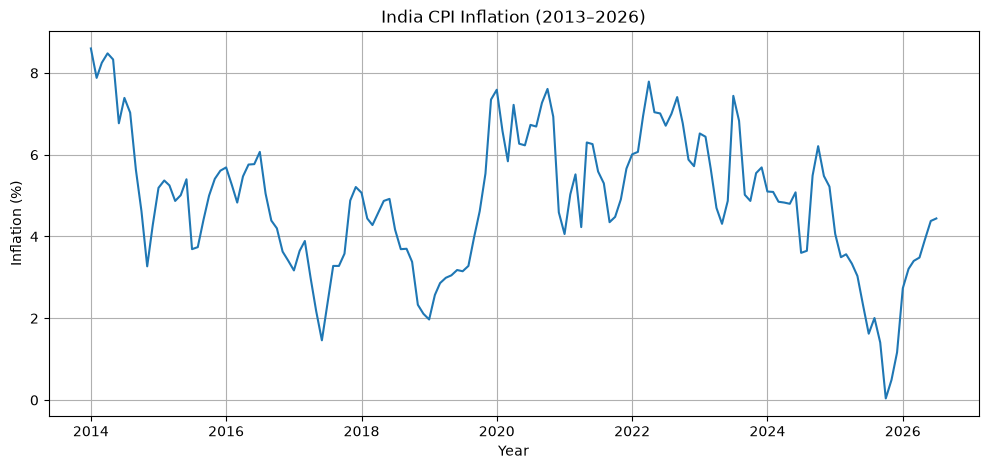

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["inflation"]
)

plt.title("India CPI Inflation (2013–2026)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")

plt.grid(True)

plt.show()

<h2>Monthly seasonality

In [9]:
monthly_avg = (
    df.groupby("month")["inflation"]
    .mean()
)

monthly_avg

month
April        4.997820
August       4.795492
December     4.668015
February     5.006232
January      5.059061
July         4.843357
June         4.895035
March        5.011351
May          4.991431
November     4.525229
October      4.614881
September    4.695635
Name: inflation, dtype: float64

In [10]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_avg = (
    df.groupby("month")["inflation"]
    .mean()
    .reindex(month_order)
)

monthly_avg

month
January      5.059061
February     5.006232
March        5.011351
April        4.997820
May          4.991431
June         4.895035
July         4.843357
August       4.795492
September    4.695635
October      4.614881
November     4.525229
December     4.668015
Name: inflation, dtype: float64

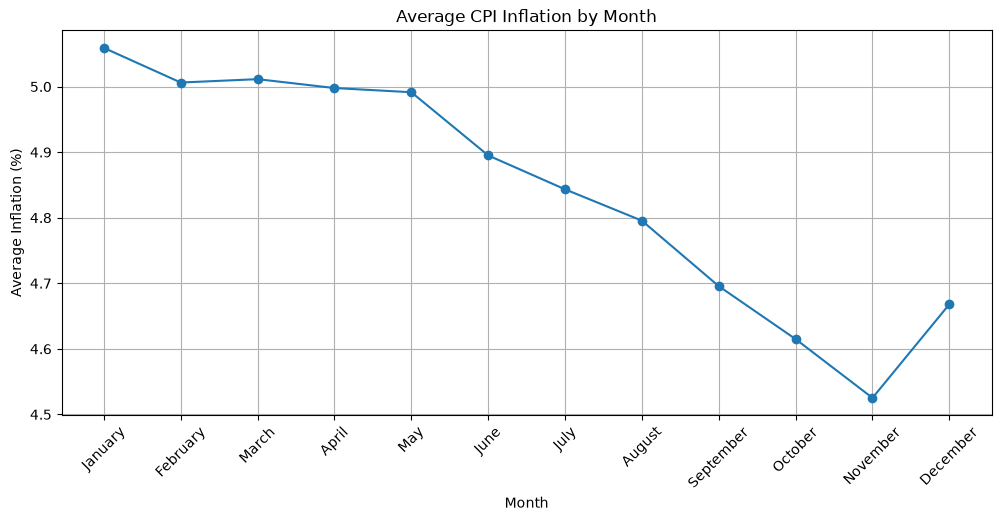

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average CPI Inflation by Month")
plt.xlabel("Month")
plt.ylabel("Average Inflation (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

<h3>Does last month's inflation help predict this month's inflation?

In [12]:
df["inflation_lag_1"] = df["inflation"].shift(1)
df["inflation_lag_3"] = df["inflation"].shift(3)
df["inflation_lag_6"] = df["inflation"].shift(6)
df["inflation_lag_12"] = df["inflation"].shift(12)

df[
    [
        "date",
        "inflation",
        "inflation_lag_1",
        "inflation_lag_3",
        "inflation_lag_6",
        "inflation_lag_12"
    ]
].tail(15)

,date,inflation,inflation_lag_1,inflation_lag_3,inflation_lag_6,inflation_lag_12
148,2025-05-01,3.033367,3.336724,3.493361,5.480000,4.800000
149,2025-06-01,2.305389,3.033367,3.564862,5.220000,5.080000
150,2025-07-01,1.622419,2.305389,3.336724,4.063460,3.600000
151,2025-08-01,2.005900,1.622419,3.033367,3.493361,3.650000
152,2025-09-01,1.407625,2.005900,2.305389,3.564862,5.490000
153,2025-10-01,0.038573,1.407625,1.622419,3.336724,6.210000
154,2025-11-01,0.492754,0.038573,2.005900,3.033367,5.480000
155,2025-12-01,1.166181,0.492754,1.407625,2.305389,5.220000
156,2026-01-01,2.734337,1.166181,0.038573,1.622419,4.063460
157,2026-02-01,3.207659,2.734337,0.492754,2.005900,3.493361


<h3>Measure relationships

In [13]:
lag_correlations = {
    "Lag 1 month": df["inflation"].corr(df["inflation_lag_1"]),
    "Lag 3 months": df["inflation"].corr(df["inflation_lag_3"]),
    "Lag 6 months": df["inflation"].corr(df["inflation_lag_6"]),
    "Lag 12 months": df["inflation"].corr(df["inflation_lag_12"])
}

pd.Series(lag_correlations)

Lag 1 month      0.898816
Lag 3 months     0.669515
Lag 6 months     0.438008
Lag 12 months   -0.035889
dtype: float64

<h3>Visualize Lag -1

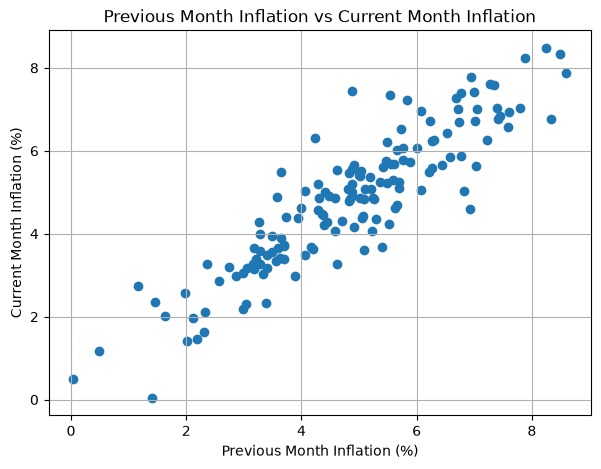

In [14]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["inflation_lag_1"],
    df["inflation"]
)

plt.title("Previous Month Inflation vs Current Month Inflation")
plt.xlabel("Previous Month Inflation (%)")
plt.ylabel("Current Month Inflation (%)")

plt.grid(True)

plt.show()

<h3>Investigate seasonality properly

<Figure size 1200x600 with 0 Axes>

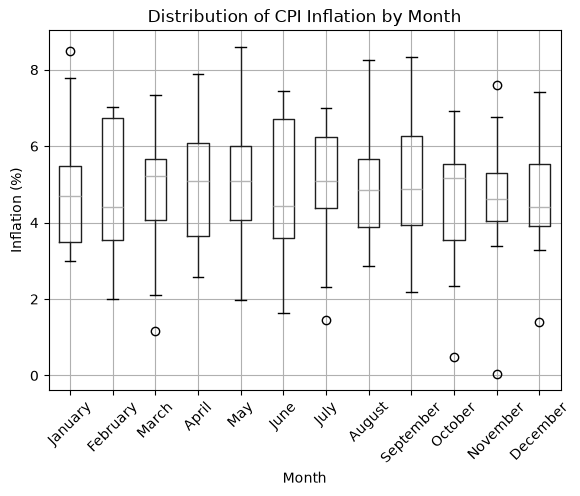

In [15]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="inflation",
    by="month",
    grid=True
)

plt.title("Distribution of CPI Inflation by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Inflation (%)")

plt.xticks(
    range(1, 13),
    month_order,
    rotation=45
)

plt.show()

In [16]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x500 with 0 Axes>

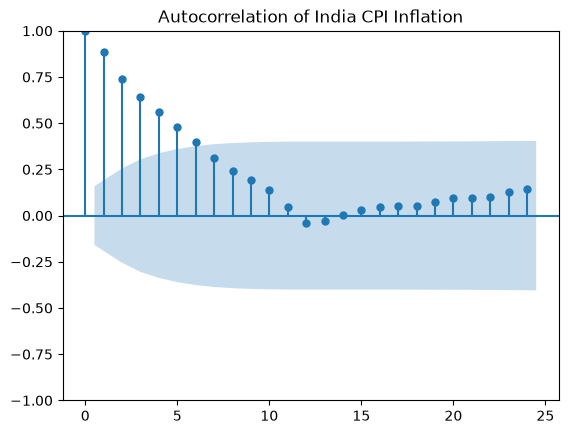

In [17]:
plt.figure(figsize=(12, 5))

plot_acf(
    df["inflation"].dropna(),
    lags=24
)

plt.title("Autocorrelation of India CPI Inflation")

plt.show()

In [18]:
df[
    (df["date"] >= "2024-07-01") &
    (df["date"] <= "2026-07-01")
][
    ["date", "cpi_index", "inflation"]
]

,date,cpi_index,inflation
138,2024-07-01,101.70,3.600000
139,2024-08-01,101.70,3.650000
140,2024-09-01,102.30,5.490000
141,2024-10-01,103.70,6.210000
142,2024-11-01,103.50,5.480000
143,2024-12-01,102.90,5.220000
144,2025-01-01,101.67,4.063460
145,2025-02-01,101.32,3.493361
146,2025-03-01,101.39,3.564862
147,2025-04-01,101.58,3.336724


In [19]:
df[
    (df["date"] >= "2024-07-01") &
    (df["date"] <= "2026-07-01")
]["cpi_index"].diff()

138     NaN
139    0.00
140    0.60
141    1.40
142   -0.20
143   -0.60
144   -1.23
145   -0.35
146    0.07
147    0.19
148    0.32
149    0.61
150    0.84
151    0.39
152    0.00
153    0.00
154    0.27
155    0.09
156    0.35
157    0.12
158    0.27
159    0.28
160    0.79
161    1.09
162    0.94
Name: cpi_index, dtype: float64

<h3>Create WPI Lag variables

In [20]:
cpi_wpi = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cpi_wpi_master.csv"
)

cpi_wpi["date"] = pd.to_datetime(cpi_wpi["date"])

cpi_wpi.head()

,date,year,month,cpi_index,inflation,wpi_index,wpi_inflation
0,2023-04-01,2023,April,93.8,4.70,99.0,NaN
1,2023-05-01,2023,May,94.3,4.31,98.6,NaN
2,2023-06-01,2023,June,95.3,4.87,98.3,NaN
3,2023-07-01,2023,July,98.1,7.44,99.1,NaN
4,2023-08-01,2023,August,98.1,6.83,99.5,NaN


In [21]:
for lag in [1, 2, 3, 6, 12]:
    cpi_wpi[f"wpi_inflation_lag_{lag}"] = (
        cpi_wpi["wpi_inflation"].shift(lag)
    )

<h3>Calculate correlation

In [22]:
wpi_lag_correlations = {
    "WPI current": (
        cpi_wpi["wpi_inflation"]
        .corr(cpi_wpi["inflation"])
    ),

    "WPI lag 1": (
        cpi_wpi["wpi_inflation_lag_1"]
        .corr(cpi_wpi["inflation"])
    ),

    "WPI lag 2": (
        cpi_wpi["wpi_inflation_lag_2"]
        .corr(cpi_wpi["inflation"])
    ),

    "WPI lag 3": (
        cpi_wpi["wpi_inflation_lag_3"]
        .corr(cpi_wpi["inflation"])
    ),

    "WPI lag 6": (
        cpi_wpi["wpi_inflation_lag_6"]
        .corr(cpi_wpi["inflation"])
    ),

    "WPI lag 12": (
        cpi_wpi["wpi_inflation_lag_12"]
        .corr(cpi_wpi["inflation"])
    )
}

pd.Series(wpi_lag_correlations)

WPI current    0.417901
WPI lag 1      0.457240
WPI lag 2      0.482814
WPI lag 3      0.548460
WPI lag 6      0.206361
WPI lag 12    -0.780017
dtype: float64

<h3>p-value test

In [23]:
from scipy.stats import pearsonr

results = []

for lag in [0, 1, 2, 3, 6, 12]:

    if lag == 0:
        wpi_series = cpi_wpi["wpi_inflation"]
    else:
        wpi_series = cpi_wpi[f"wpi_inflation_lag_{lag}"]

    valid = pd.concat(
        [
            wpi_series,
            cpi_wpi["inflation"]
        ],
        axis=1
    ).dropna()

    correlation, p_value = pearsonr(
        valid.iloc[:, 0],
        valid.iloc[:, 1]
    )

    results.append({
        "lag": lag,
        "observations": len(valid),
        "correlation": correlation,
        "p_value": p_value
    })

correlation_results = pd.DataFrame(results)

correlation_results

,lag,observations,correlation,p_value
0,0,28,0.417901,0.026905
1,1,27,0.457240,0.016490
2,2,26,0.482814,0.012479
3,3,25,0.548460,0.004529
4,6,22,0.206361,0.356846
5,12,16,-0.780017,0.000365
